In [6]:
import keras
import optuna
import polars as pl
import numpy as np
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


from keras import Sequential
from keras.layers import Input, Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import *
from keras.utils import image_dataset_from_directory
from matplotlib import pyplot as plt 
from pathlib import Path

I0000 00:00:1779938472.521052  114616 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779938472.547835  114616 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779938473.106067  114616 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/davi/Documents/GitHub/autotuning_cnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Pleas

In [7]:
DATA_DIR_TRAIN = "data/seg_train/seg_train"
DATA_DIR_TEST = "data/seg_test/seg_test"
IMG_SIZE = (150,150)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 69

In [8]:
df_train = image_dataset_from_directory(
    directory=DATA_DIR_TRAIN,
    image_size=IMG_SIZE,
    batch_size=16,
    seed=SEED,
    validation_split=0.2,
    subset="training"
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1779938474.031787  114616 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5457 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


In [9]:
df_validation= image_dataset_from_directory(
    directory=DATA_DIR_TRAIN,
    image_size=IMG_SIZE,
    batch_size=16,
    seed=SEED,
    validation_split=0.2,
    subset="validation"
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [10]:
df_teste = image_dataset_from_directory(
    directory=DATA_DIR_TEST,
    image_size=IMG_SIZE,
    batch_size=16,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [11]:
print("Classes:", df_train.class_names)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [12]:
for imgs, lbls in df_train.take(1):
    print("Shape do batch de imagens:", imgs.shape)
    print("Shape do batch de rótulos:", lbls.shape)
    print("Range de pixels:", imgs.numpy().min(), "a", imgs.numpy().max())


Shape do batch de imagens: (16, 150, 150, 3)
Shape do batch de rótulos: (16,)
Range de pixels: 0.0 a 255.0


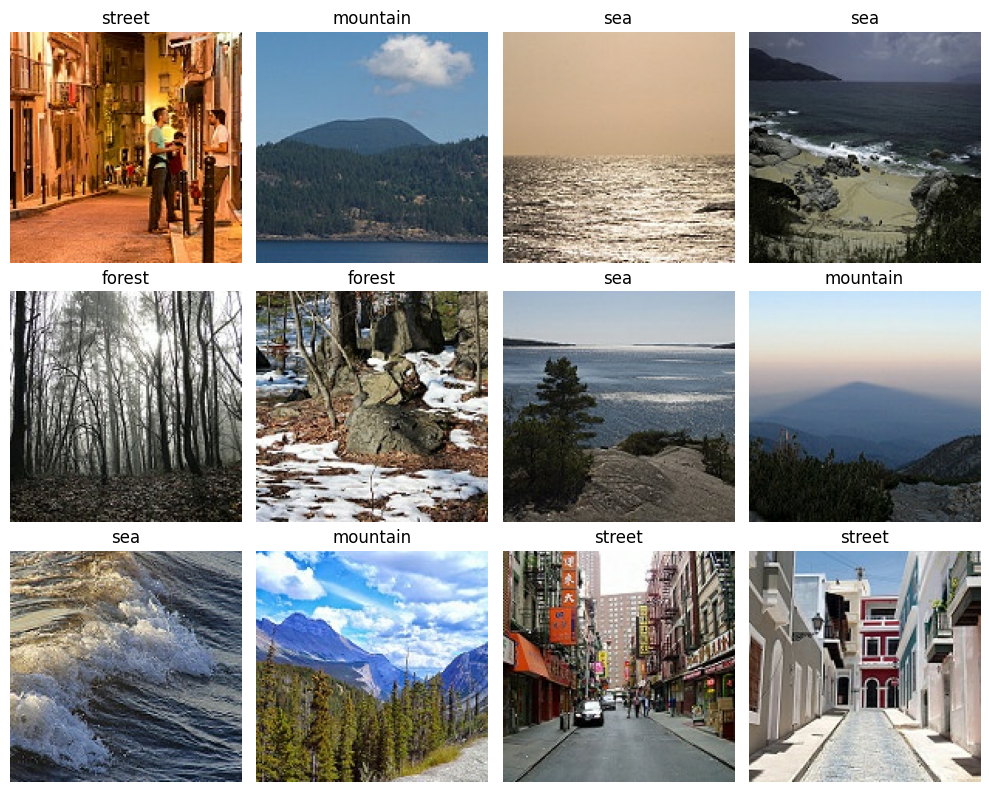

In [13]:
class_names = df_train.class_names

plt.figure(figsize=(10, 8))
for imgs, lbls in df_train.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(imgs[i].numpy().astype("uint8"))   # converte pro tipo certo pra exibir
        plt.title(class_names[lbls[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()


In [14]:
num_classes = len(class_names)

model = Sequential([
    Input(shape=(150,150,3)),
    Rescaling(1./255),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,637,126 (40.58 MB)

 Trainable params: 10,637,126 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    df_train,
    validation_data=df_validation,
    epochs=EPOCHS
)

Epoch 1/20


I0000 00:00:1779938476.049091  125310 service.cc:153] XLA service 0x761b8c0318c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779938476.049106  125310 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779938476.065647  125310 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779938476.145607  125310 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779938476.165594  125310 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1830__.31


 20/702 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1845 - loss: 4.0127

I0000 00:00:1779938478.841438  125310 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


700/702 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4992 - loss: 1.4037

I0000 00:00:1779938485.859337  125312 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1830__.31


702/702 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.5968 - loss: 1.0704 - val_accuracy: 0.7252 - val_loss: 0.7271
Epoch 2/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7414 - loss: 0.7044 - val_accuracy: 0.7527 - val_loss: 0.6633
Epoch 3/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8123 - loss: 0.5262 - val_accuracy: 0.7783 - val_loss: 0.6461
Epoch 4/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8733 - loss: 0.3571 - val_accuracy: 0.7641 - val_loss: 0.7800
Epoch 5/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9173 - loss: 0.2348 - val_accuracy: 0.7609 - val_loss: 0.9239
Epoch 6/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9393 - loss: 0.1704 - val_accuracy: 0.7666 - val_loss: 0.9745
Epoch 7/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9503 - loss: 0.1460 - val_accuracy: 0.7698 - val_loss: 1.0784
Epoch 8/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9595 - loss: 0.1216 - val_accuracy: 0.77

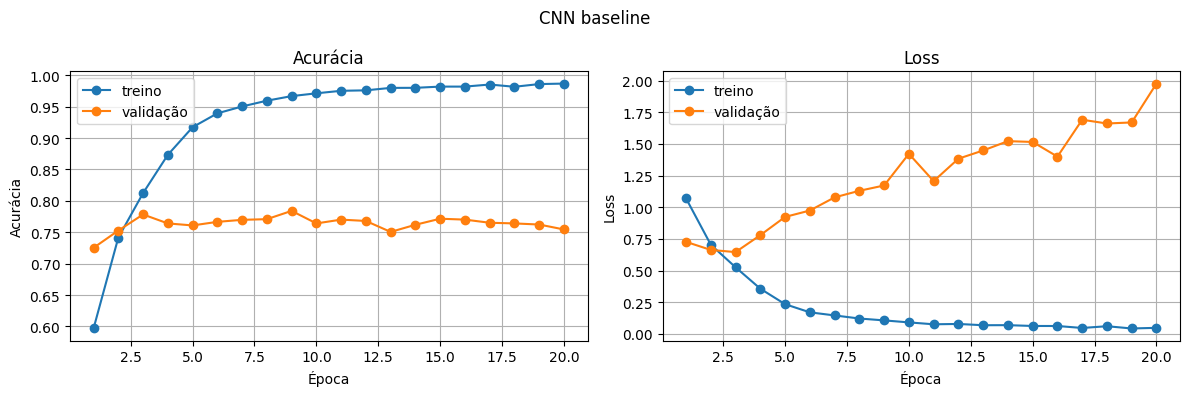

In [17]:
def plotar_curvas(history, titulo="Treino vs Validação"):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, acc, marker="o", label="treino")
    axes[0].plot(epochs_range, val_acc, marker="o", label="validação")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Acurácia")
    axes[0].set_title("Acurácia")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs_range, loss, marker="o", label="treino")
    axes[1].plot(epochs_range, val_loss, marker="o", label="validação")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Loss")
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()


plotar_curvas(history, "CNN baseline")

In [18]:
# Avaliação no conjunto de teste (separado desde o início)
test_loss, test_acc = model.evaluate(df_teste, verbose=1)
print(f"Loss no teste:    {test_loss:.4f}")
print(f"Acurácia no teste: {test_acc:.4f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7703 - loss: 1.8397
Loss no teste:    1.8397
Acurácia no teste: 0.7703


o modelo ficou uma merda, hora de preparar a pipe pro tuning

1 - Preparação dos dados

In [19]:
def list_images(dir: str) -> pl.DataFrame:
    """Varre <diretorio>/<classe>/*.jpg e devolve DataFrame polars com path e classe."""
     
    paths = list(Path(dir).glob("*/*.jpg"))

    return pl.DataFrame({
        "path": [str(p) for p in paths],
        "class": [p.parent.name for p in paths]
    })

In [20]:
df_train_full = list_images(DATA_DIR_TRAIN)
df_test_full = list_images(DATA_DIR_TEST)

In [21]:
print(f"Treino: {len(df_train_full)} imagens")
print(f"Teste:  {len(df_test_full)} imagens")
df_train_full.head()

Treino: 14034 imagens
Teste:  3000 imagens


path,class
str,str
"""data/seg_train/seg_train/stree…","""street"""
"""data/seg_train/seg_train/stree…","""street"""
"""data/seg_train/seg_train/stree…","""street"""
"""data/seg_train/seg_train/stree…","""street"""
"""data/seg_train/seg_train/stree…","""street"""


Passo 2 - Fazendo um split estratificado para treino/validação em polars (sou engenheiro de dados prof, me recuso a usar pandas sempre que eu posso)

In [24]:
def stratified_split(df: pl.DataFrame, frac_val:float = 0.2, seed: int = SEED, col_class:str = "class")-> tuple[pl.DataFrame, pl.DataFrame]:
    """Separa df em treino/validação mantendo proporção de classes."""
    
    marked_df = df.with_columns(
        is_val=(
            pl.int_range(pl.len()).shuffle(seed=seed)
            < (pl.len() * frac_val).cast(pl.Int64)
        ).over(col_class)
    )
    
    validation_df = marked_df.filter(pl.col("is_val")).drop("is_val")
    train_df = marked_df.filter(~pl.col("is_val")).drop("is_val")
    
    return train_df, validation_df

In [25]:
df_train, df_validation = stratified_split(df_train_full, frac_val=0.2, seed=SEED)

In [26]:
print(f"Treino:    {len(df_train)}")
print(f"Validação: {len(df_validation)}")
print("\nDistribuição por classe:")
print(
    df_train.group_by("class").len().rename({"len": "treino"})
    .join(df_validation.group_by("class").len().rename({"len": "validacao"}), on="class")
    .sort("class")
)

Treino:    11230
Validação: 2804

Distribuição por classe:
shape: (6, 3)
┌───────────┬────────┬───────────┐
│ class     ┆ treino ┆ validacao │
│ ---       ┆ ---    ┆ ---       │
│ str       ┆ u32    ┆ u32       │
╞═══════════╪════════╪═══════════╡
│ buildings ┆ 1753   ┆ 438       │
│ forest    ┆ 1817   ┆ 454       │
│ glacier   ┆ 1924   ┆ 480       │
│ mountain  ┆ 2010   ┆ 502       │
│ sea       ┆ 1820   ┆ 454       │
│ street    ┆ 1906   ┆ 476       │
└───────────┴────────┴───────────┘


Passo 3 - retirando sub-amostras estratificadas para o tuning

In [27]:
def stratified_subsampling(
    df: pl.DataFrame,
    n_total: int,
    seed: int = SEED,
    col_class: str = "class",
) -> pl.DataFrame:
    """Amostra estratificada de aproximadamente n_total linhas."""
    
    frac = n_total / len(df)
    
    return (
        df.with_columns(
            is_sample=(
                pl.int_range(pl.len()).shuffle(seed=seed)
                < (pl.len() * frac).cast(pl.Int64)
            ).over(col_class)
        )
        .filter(pl.col("is_sample"))
        .drop("is_sample")
    )

In [28]:
df_train_tuning = stratified_subsampling(df_train, n_total=3000, seed=SEED)
df_validation_tuning = stratified_subsampling(df_validation, n_total=600, seed=SEED)

In [29]:
print(f"Treino tuning:    {len(df_train_tuning)}")
print(f"Validação tuning: {len(df_validation_tuning)}")
print("\nDistribuição treino tuning:")
print(df_train_tuning.group_by("class").len().sort("class"))

Treino tuning:    2997
Validação tuning: 597

Distribuição treino tuning:
shape: (6, 2)
┌───────────┬─────┐
│ class     ┆ len │
│ ---       ┆ --- │
│ str       ┆ u32 │
╞═══════════╪═════╡
│ buildings ┆ 468 │
│ forest    ┆ 485 │
│ glacier   ┆ 513 │
│ mountain  ┆ 536 │
│ sea       ┆ 486 │
│ street    ┆ 509 │
└───────────┴─────┘
